# EE-568 — Applied Project 2: RLHF

## Goal of this notebook
This notebook implements the first step of the RLHF pipeline: finding two policies of different quality for a given environment.

We need:
- **π₁** — an *excellent* policy that reliably achieves the maximum possible reward
- **π₂** — a *mediocre* policy that consistently achieves roughly half the maximum reward

## Conditions for a good π₁
- Mean reward close to the environment maximum
- Low standard deviation => it should be consistently excellent, not just occasionally lucky

## Conditions for a good π₂
- Mean reward around half the environment maximum
- **Low standard deviation** => hardest condition to satisfy
- Must be clearly worse than π₁ so that the preference labeling formula produces a meaningful signal

## Why std matters for π₂
If π₂ sometimes performs as well as π₁, the preference label becomes a coin flip (probability ≈ 0.5),
providing no useful learning signal. We need π₂ to be *consistently* mediocre.

## What we tried
- **CartPole-v1**: rejected — the policy learns too fast, no stable mediocre zone exists
- **Acrobot-v1**: selected — wider learning curve, genuine stable mediocre zone exists
- **MountainCar-v0** and **MountainCarContinuous-v0**: explored as additional environment candidates

## Setup

Ensure the required packages are installed before running. In your terminal:

```bash
pip install stable-baselines3 gymnasium
```

**Apple Silicon (M1/M2) note:** all models use `device="cpu"`, which is the correct and stable choice.
MPS support in Stable-Baselines3 is experimental and unreliable for RL training.

In [1]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
save_path = os.path.join("outputs", "checkpoints")
os.makedirs(save_path, exist_ok=True)
print(f"Checkpoints will be saved to: {os.path.abspath(save_path)}")

Checkpoints will be saved to: /home/misenta/RL/EE-568-Reinforcement-Project/outputs/checkpoints


# CartPole


In [3]:
env = gym.make("CartPole-v1")

checkpoints = [2_000, 4_000, 6_000, 8_000, 10_000, 12_000, 15_000, 20_000]
results = []

for timesteps in checkpoints:
    model = PPO("MlpPolicy", env, verbose=0, device="cpu", seed=0)
    model.learn(total_timesteps=timesteps)

    mean_reward, std_reward = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True
    )

    results.append((timesteps, mean_reward, std_reward))
    print(f"{timesteps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    model.save(os.path.join(save_path, f"cartpole_{timesteps}steps"))

/home/misenta/miniconda3/envs/rl-v100/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


2000 steps: 173.2 +/- 140.4
4000 steps: 347.9 +/- 155.8
6000 steps: 289.7 +/- 148.2
8000 steps: 415.7 +/- 117.5


KeyboardInterrupt: 

## Seed 0 fine-grained sweep

1024 steps: 111.5 +/- 39.4
2048 steps: 133.5 +/- 50.9
3072 steps: 123.9 +/- 35.7
4096 steps: 104.0 +/- 34.5
5120 steps: 97.2 +/- 31.4
6144 steps: 110.4 +/- 29.8
7168 steps: 132.0 +/- 48.4
8192 steps: 136.9 +/- 52.0
9216 steps: 148.8 +/- 45.5
10240 steps: 183.6 +/- 82.2
11264 steps: 198.9 +/- 70.1
12288 steps: 210.5 +/- 62.6
13312 steps: 295.2 +/- 116.6
14336 steps: 280.6 +/- 102.9
15360 steps: 500.0 +/- 0.0
Policy is now too good at 15360 steps, stopping


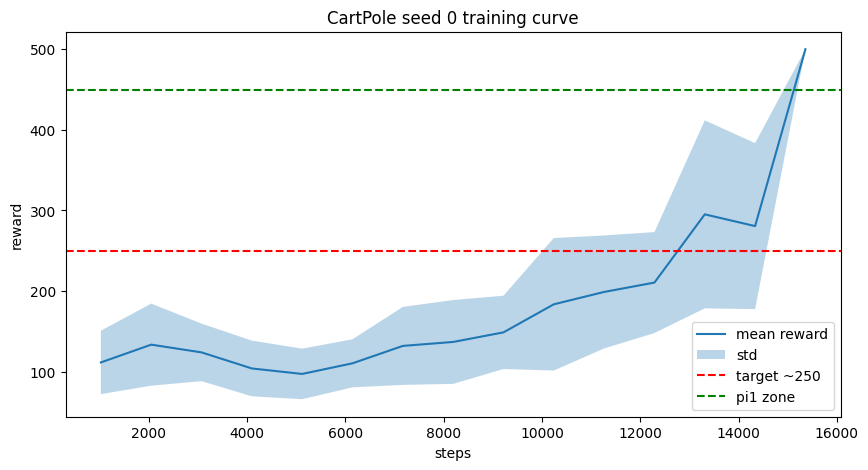

In [ ]:
env_train = gym.make("CartPole-v1")
env_eval  = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(250, color="red",   linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 0 training curve")
plt.legend()
plt.show()

## Seed 1 fine-grained sweep

1024 steps: 65.7 +/- 24.2
2048 steps: 67.8 +/- 23.8
3072 steps: 80.2 +/- 30.9
4096 steps: 112.4 +/- 44.3
5120 steps: 115.9 +/- 54.3
6144 steps: 133.5 +/- 65.2
7168 steps: 118.2 +/- 56.6
8192 steps: 106.2 +/- 40.6
9216 steps: 148.1 +/- 68.7
10240 steps: 173.5 +/- 73.9
11264 steps: 198.8 +/- 87.0
12288 steps: 223.3 +/- 89.3
13312 steps: 237.5 +/- 85.4
14336 steps: 260.4 +/- 79.0
15360 steps: 498.7 +/- 7.5
Policy is now too good at 15360 steps, stopping


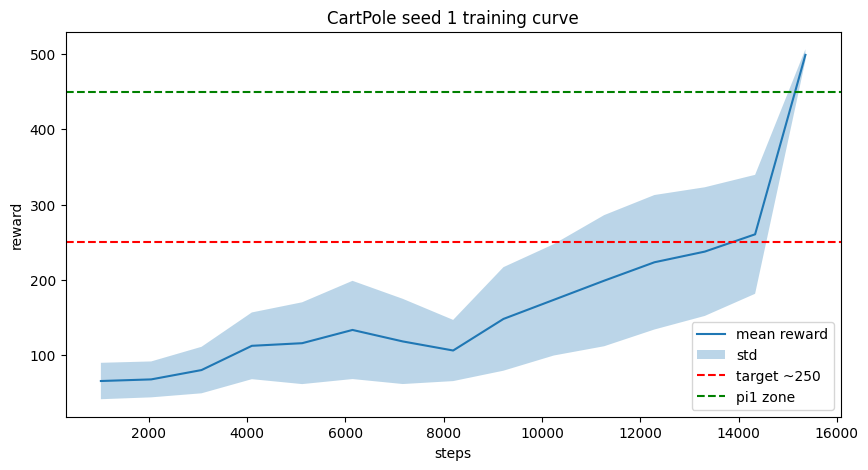

In [ ]:
env_train = gym.make("CartPole-v1")
env_eval  = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(250, color="red",   linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 1 training curve")
plt.legend()
plt.show()

## Seed 2 fine-grained sweep

1024 steps: 85.8 +/- 34.3
2048 steps: 92.9 +/- 47.7
3072 steps: 133.8 +/- 82.6
4096 steps: 144.8 +/- 79.4
5120 steps: 146.0 +/- 81.5
6144 steps: 134.5 +/- 108.1
7168 steps: 100.6 +/- 55.7
8192 steps: 143.3 +/- 96.2
9216 steps: 108.4 +/- 56.8
10240 steps: 115.5 +/- 54.8
11264 steps: 180.6 +/- 104.1
12288 steps: 156.6 +/- 77.0
13312 steps: 212.9 +/- 92.0
14336 steps: 231.4 +/- 84.9
15360 steps: 287.8 +/- 85.8
16384 steps: 492.7 +/- 29.0
Policy is now too good at 16384 steps, stopping


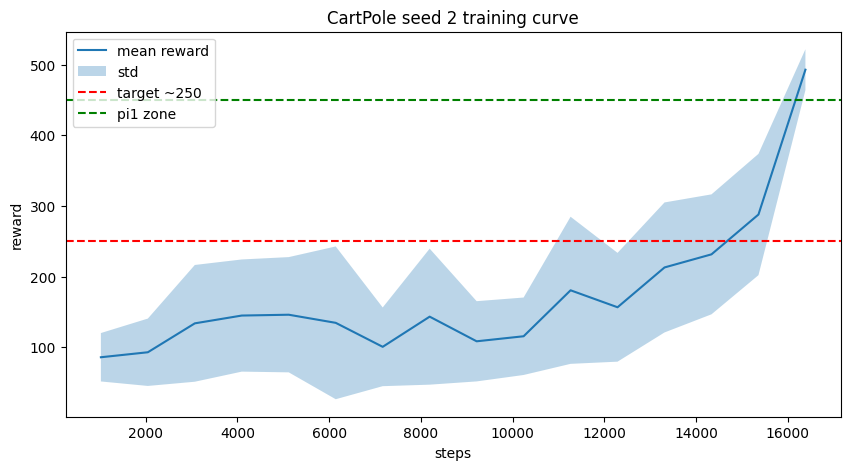

In [ ]:
env_train = gym.make("CartPole-v1")
env_eval  = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=2,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(250, color="red",   linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 2 training curve")
plt.legend()
plt.show()

## Seed 3 fine-grained sweep

1024 steps: 96.4 +/- 42.1
2048 steps: 90.7 +/- 45.7
3072 steps: 76.1 +/- 25.5
4096 steps: 114.7 +/- 61.8
5120 steps: 113.5 +/- 60.3
6144 steps: 132.6 +/- 72.2
7168 steps: 150.8 +/- 84.3
8192 steps: 140.0 +/- 68.2
9216 steps: 149.8 +/- 78.9
10240 steps: 168.9 +/- 94.2
11264 steps: 164.3 +/- 93.9
12288 steps: 151.6 +/- 94.4
13312 steps: 157.4 +/- 77.7
14336 steps: 207.1 +/- 75.6
15360 steps: 289.6 +/- 119.7
16384 steps: 326.3 +/- 107.6
17408 steps: 407.8 +/- 104.1
18432 steps: 304.2 +/- 111.8
19456 steps: 333.6 +/- 135.9
20480 steps: 365.6 +/- 123.8
21504 steps: 418.3 +/- 90.5
22528 steps: 498.3 +/- 13.6
Policy is now too good at 22528 steps, stopping


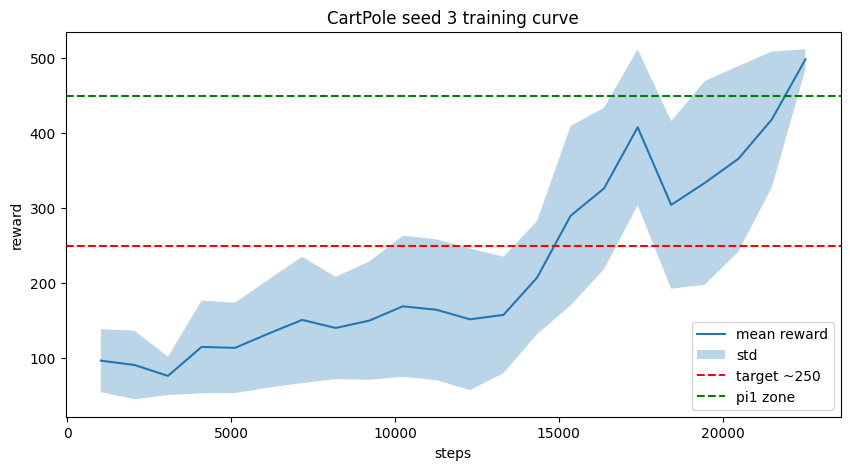

In [ ]:
env_train = gym.make("CartPole-v1")
env_eval  = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=3,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(250, color="red",   linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 3 training curve")
plt.legend()
plt.show()

## Seed 4 fine-grained sweep

1024 steps: 97.0 +/- 39.8
2048 steps: 103.8 +/- 43.6
3072 steps: 100.4 +/- 40.2
4096 steps: 98.7 +/- 41.0
5120 steps: 88.1 +/- 39.5
6144 steps: 94.6 +/- 33.5
7168 steps: 135.2 +/- 67.4
8192 steps: 150.1 +/- 62.7
9216 steps: 155.0 +/- 65.6
10240 steps: 160.4 +/- 61.5
11264 steps: 177.8 +/- 69.4
12288 steps: 200.5 +/- 59.8
13312 steps: 268.4 +/- 84.1
14336 steps: 347.3 +/- 78.9
15360 steps: 385.3 +/- 73.4
16384 steps: 494.3 +/- 18.0
Policy is now too good at 16384 steps, stopping


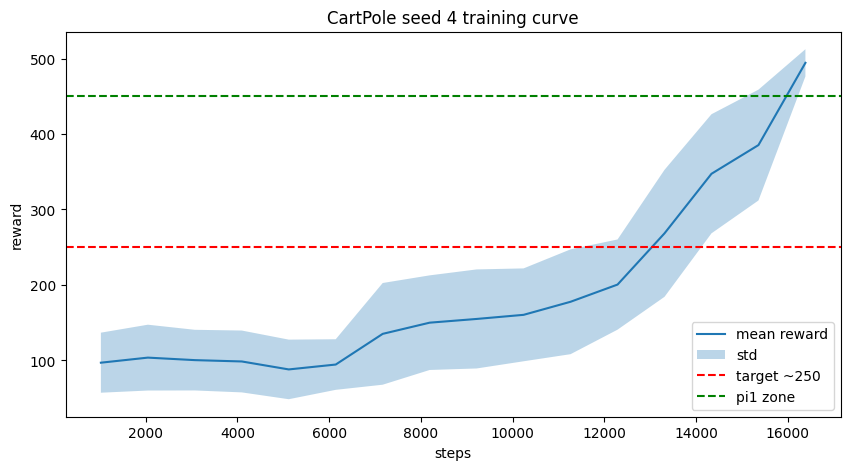

In [ ]:
env_train = gym.make("CartPole-v1")
env_eval  = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=4,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(250, color="red",   linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 4 training curve")
plt.legend()
plt.show()

# Acrobot


In [ ]:
env_acrobot = gym.make("Acrobot-v1")
checkpoints = [5_000, 10_000, 20_000, 40_000, 60_000, 80_000, 100_000]
results_acrobot = []

for timesteps in checkpoints:
    model = PPO("MlpPolicy", env_acrobot, verbose=0, device="cpu", seed=0)
    model.learn(total_timesteps=timesteps)
    mean_reward, std_reward = evaluate_policy(
        model, env_acrobot, n_eval_episodes=100, deterministic=True
    )
    results_acrobot.append((timesteps, mean_reward, std_reward))
    print(f"{timesteps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

5000 steps: -500.0 +/- 0.0
10000 steps: -500.0 +/- 0.0
20000 steps: -500.0 +/- 0.0
40000 steps: -475.8 +/- 82.7
60000 steps: -84.1 +/- 22.6
80000 steps: -82.8 +/- 12.2
100000 steps: -84.9 +/- 18.9


## Seed 0 fine-grained sweep

1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -143.0 +/- 37.9
Policy is now too good at 4096 steps, stopping


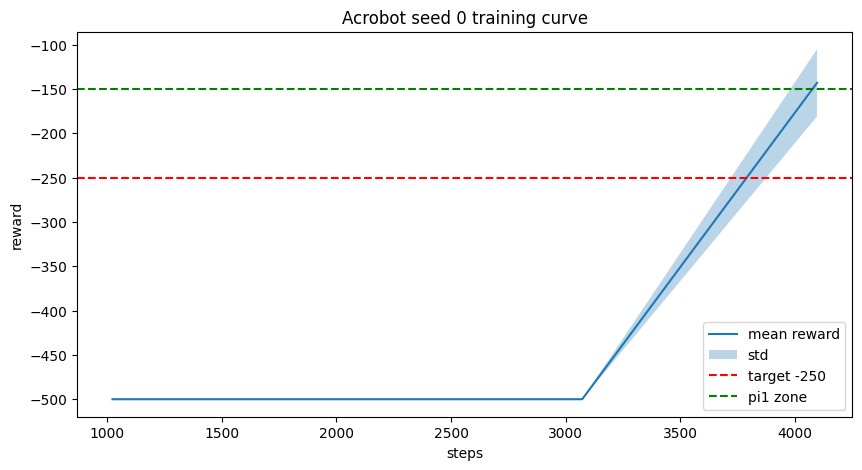

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=0)
env_eval.reset(seed=10_000 + 0)

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 0 training curve")
plt.legend()
plt.show()

Finished silent training to 11264 steps
11392 steps: -289.6 +/- 196.0
11520 steps: -235.3 +/- 177.0
11648 steps: -185.9 +/- 154.0
11776 steps: -217.3 +/- 176.2
11904 steps: -198.3 +/- 167.4
12032 steps: -187.1 +/- 161.5
12160 steps: -193.7 +/- 165.5
12288 steps: -134.1 +/- 116.0
Too good, stopping


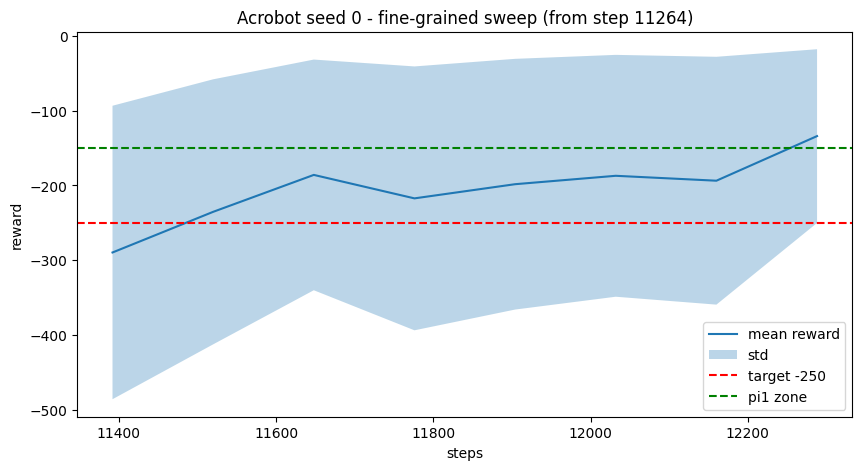

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=0)
env_eval.reset(seed=10_000 + 0)

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# Train silently to the interesting zone
model.learn(total_timesteps=11264, reset_num_timesteps=True)
total_steps = 11264
print(f"Finished silent training to {total_steps} steps")

# Fine-grained sweep from 11264 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 0 - fine-grained sweep (from step 11264)")
plt.legend()
plt.show()

Finished silent training to 3072 steps
3200 steps: -259.8 +/- 142.8
3328 steps: -150.8 +/- 29.4
3456 steps: -139.7 +/- 27.2
Too good, stopping


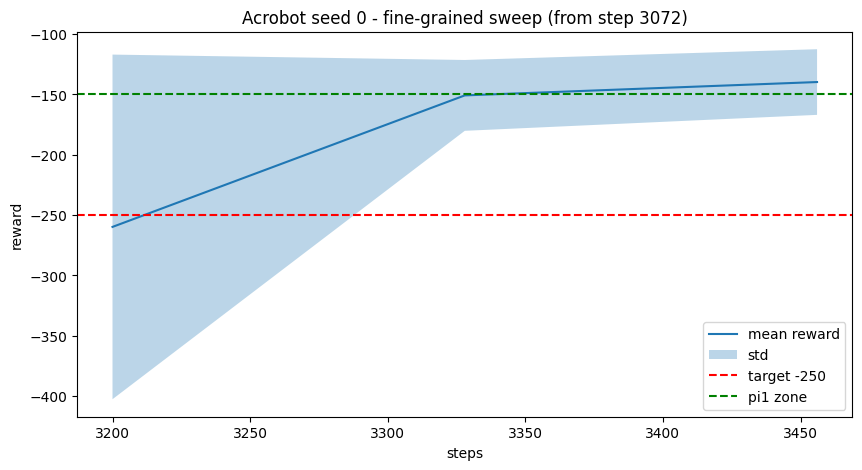

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=0)
env_eval.reset(seed=10_000 + 0)

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# Train silently to the interesting zone
model.learn(total_timesteps=3072, reset_num_timesteps=True)
total_steps = 3072
print(f"Finished silent training to {total_steps} steps")

# Fine-grained sweep from 3072 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 0 - fine-grained sweep (from step 3072)")
plt.legend()
plt.show()

## Seed 1 fine-grained sweep

1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -500.0 +/- 0.0
5120 steps: -500.0 +/- 0.0
6144 steps: -500.0 +/- 0.0
7168 steps: -341.1 +/- 180.3
8192 steps: -143.6 +/- 130.7
Policy is now too good at 8192 steps, stopping


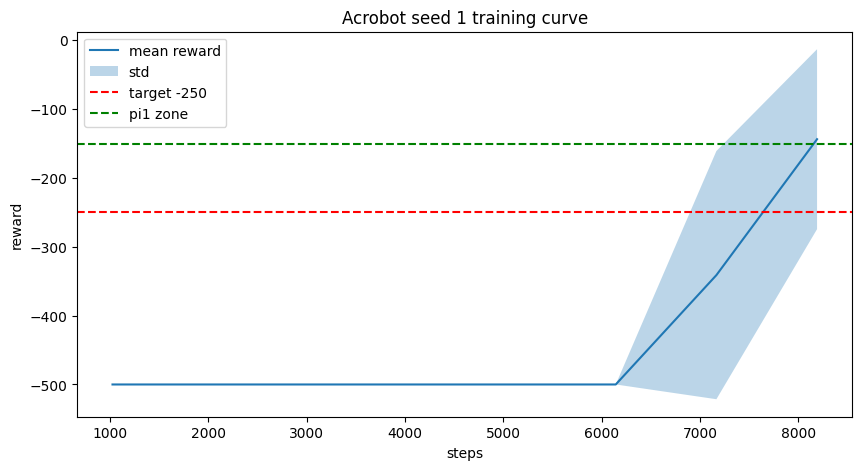

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=1)
env_eval.reset(seed=10_000 + 1)

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 1 training curve")
plt.legend()
plt.show()

Finished silent training to 7168 steps
7296 steps: -253.5 +/- 183.8
7424 steps: -193.4 +/- 172.4
7552 steps: -145.2 +/- 129.3
Too good, stopping


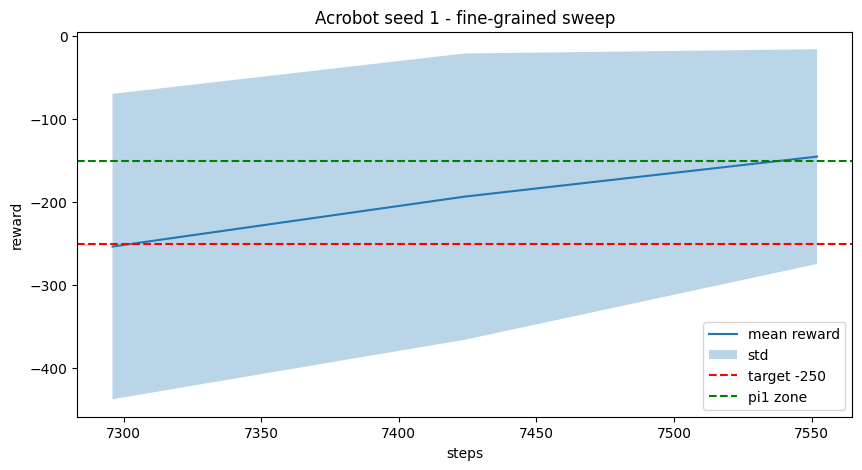

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=1)
env_eval.reset(seed=10_000 + 1)

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# Train silently to the interesting zone
model.learn(total_timesteps=7168, reset_num_timesteps=True)
total_steps = 7168
print(f"Finished silent training to {total_steps} steps")

# Fine-grained sweep from 7168 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 1 - fine-grained sweep")
plt.legend()
plt.show()

## Seed 2 fine-grained sweep

1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -500.0 +/- 0.0
5120 steps: -500.0 +/- 0.0
6144 steps: -500.0 +/- 0.0
7168 steps: -500.0 +/- 0.0
8192 steps: -500.0 +/- 0.0
9216 steps: -500.0 +/- 0.0
10240 steps: -500.0 +/- 0.0
11264 steps: -500.0 +/- 0.0
12288 steps: -439.4 +/- 144.5
13312 steps: -500.0 +/- 0.0
14336 steps: -500.0 +/- 0.0
15360 steps: -370.2 +/- 187.2
16384 steps: -314.6 +/- 201.8
17408 steps: -218.5 +/- 187.0
18432 steps: -202.9 +/- 174.7
19456 steps: -196.2 +/- 177.4
20480 steps: -326.0 +/- 201.8
21504 steps: -373.1 +/- 188.5
22528 steps: -331.1 +/- 199.7
23552 steps: -242.5 +/- 191.7
24576 steps: -152.9 +/- 148.0
25600 steps: -167.1 +/- 167.3
26624 steps: -132.4 +/- 121.2
Policy is now too good at 26624 steps, stopping


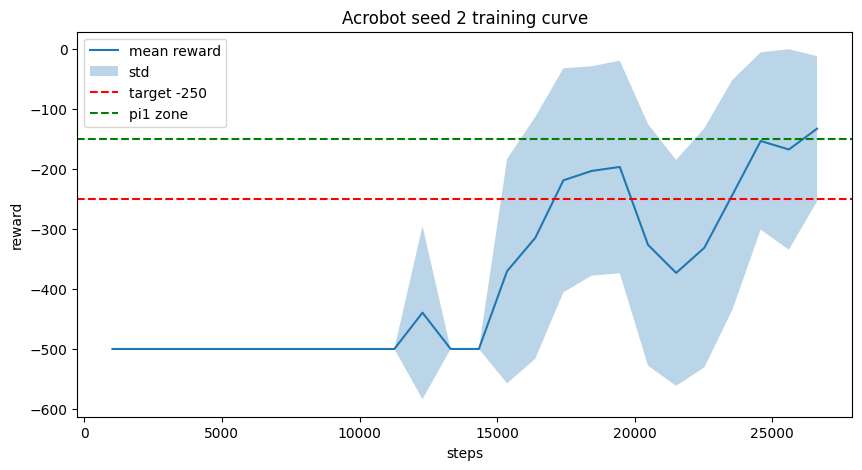

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=2)
env_eval.reset(seed=10_000 + 2)

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=2,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 2 training curve")
plt.legend()
plt.show()

## Seed 3 fine-grained sweep

### Exploration from step 15360
Continued training with smaller checkpoint intervals starting from step 15360.
Results were not satisfying (policy either stayed stuck or jumped past the target zone).

In [ ]:
# Originally this cell loaded a checkpoint from Google Drive and continued training.
# Converted to retrain from scratch to the same starting point for local execution.
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

seed        = 3
start_steps = 15360

for checkpoint_interval in [256, 128]:
    print(f"\n=== checkpoint_interval={checkpoint_interval} ===")
    print(f"\n--- seed {seed}, retraining from scratch to {start_steps} steps ---")

    model = PPO(
        "MlpPolicy", env_train,
        verbose=0, device="cpu", seed=seed,
        learning_rate=1e-4, n_steps=256, batch_size=64,
        n_epochs=5, ent_coef=0.01, gamma=0.99,
    )
    model.learn(total_timesteps=start_steps, reset_num_timesteps=True)
    total_steps = start_steps

    for _ in range(0, 10_000, checkpoint_interval):
        model.learn(
            total_timesteps=checkpoint_interval,
            reset_num_timesteps=False
        )
        total_steps += checkpoint_interval
        mean_reward, std_reward = evaluate_policy(
            model, env_eval, n_eval_episodes=100, deterministic=True
        )
        print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

        if mean_reward > -150:
            print("Too good, stopping")
            break


=== checkpoint_interval=256 ===

--- seed 3, retraining from scratch to 15360 steps ---
15616 steps: -226.9 +/- 121.0
15872 steps: -148.6 +/- 55.1
Too good, stopping

=== checkpoint_interval=128 ===

--- seed 3, retraining from scratch to 15360 steps ---
15488 steps: -208.6 +/- 120.9
15616 steps: -166.6 +/- 86.3
15744 steps: -132.6 +/- 32.4
Too good, stopping


### Exploration from step 14336
Same experiment starting from step 14336 instead. Results were also not satisfying.

In [ ]:
# Originally this cell loaded a checkpoint from Google Drive and continued training.
# Converted to retrain from scratch to the same starting point for local execution.
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

seed        = 3
start_steps = 14336

for checkpoint_interval in [256, 128]:
    print(f"\n=== checkpoint_interval={checkpoint_interval} ===")
    print(f"\n--- seed {seed}, retraining from scratch to {start_steps} steps ---")

    model = PPO(
        "MlpPolicy", env_train,
        verbose=0, device="cpu", seed=seed,
        learning_rate=1e-4, n_steps=256, batch_size=64,
        n_epochs=5, ent_coef=0.01, gamma=0.99,
    )
    model.learn(total_timesteps=start_steps, reset_num_timesteps=True)
    total_steps = start_steps

    for _ in range(0, 10_000, checkpoint_interval):
        model.learn(
            total_timesteps=checkpoint_interval,
            reset_num_timesteps=False
        )
        total_steps += checkpoint_interval
        mean_reward, std_reward = evaluate_policy(
            model, env_eval, n_eval_episodes=100, deterministic=True
        )
        print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

        if mean_reward > -150:
            print("Too good, stopping")
            break


=== checkpoint_interval=256 ===

--- seed 3, retraining from scratch to 14336 steps ---
14592 steps: -491.4 +/- 49.0
14848 steps: -484.1 +/- 69.3
15104 steps: -415.8 +/- 138.9
15360 steps: -302.4 +/- 166.1
15616 steps: -199.9 +/- 110.4
15872 steps: -173.7 +/- 95.0
16128 steps: -136.7 +/- 44.4
Too good, stopping

=== checkpoint_interval=128 ===

--- seed 3, retraining from scratch to 14336 steps ---
14464 steps: -496.5 +/- 35.0
14592 steps: -478.9 +/- 77.5
14720 steps: -420.7 +/- 133.9
14848 steps: -293.2 +/- 161.8
14976 steps: -234.8 +/- 134.9
15104 steps: -162.6 +/- 84.6
15232 steps: -135.7 +/- 39.8
Too good, stopping


### Retrained from scratch
Retrained seed 3 entirely from scratch to confirm the issue was with checkpoint loading, not the training curve itself.

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")
checkpoint_interval = 1024

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=3,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -500.0 +/- 0.0
5120 steps: -500.0 +/- 0.0
6144 steps: -500.0 +/- 0.0
7168 steps: -500.0 +/- 0.0
8192 steps: -500.0 +/- 0.0
9216 steps: -500.0 +/- 0.0
10240 steps: -500.0 +/- 0.0
11264 steps: -500.0 +/- 0.0
12288 steps: -500.0 +/- 0.0
13312 steps: -496.3 +/- 36.8
14336 steps: -487.3 +/- 62.3
15360 steps: -286.9 +/- 160.0
16384 steps: -147.1 +/- 29.4
Policy is now too good at 16384 steps, stopping


Finished silent training to 14336 steps
14464 steps: -493.6 +/- 44.5
14592 steps: -485.3 +/- 64.7
14720 steps: -407.6 +/- 143.4
14848 steps: -320.6 +/- 161.3
14976 steps: -230.8 +/- 128.1
15104 steps: -166.8 +/- 89.0
15232 steps: -132.5 +/- 44.9
Too good, stopping


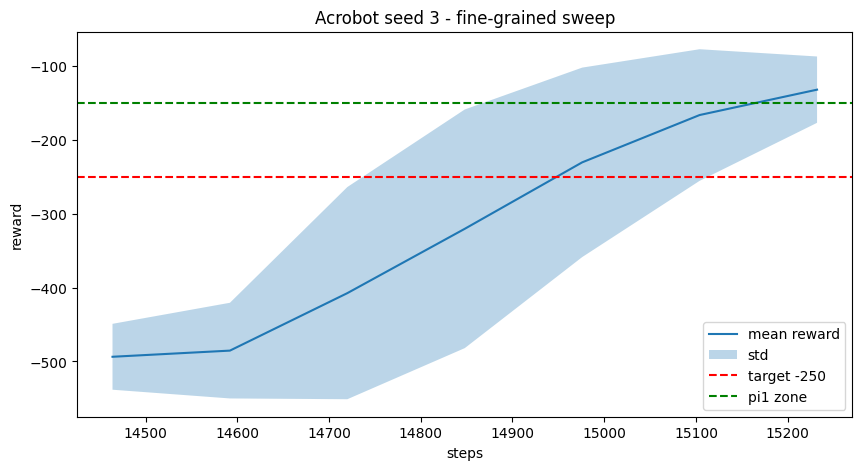

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=3)
env_eval.reset(seed=10_000 + 3)

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=3,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# Train silently to the interesting zone
model.learn(total_timesteps=14336, reset_num_timesteps=True)
total_steps = 14336
print(f"Finished silent training to {total_steps} steps")

# Fine-grained sweep from 14336 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 3 - fine-grained sweep")
plt.legend()
plt.show()

## Seed 4 fine-grained sweep

1024 steps: -291.4 +/- 182.3
2048 steps: -142.0 +/- 29.8
Policy is now too good at 2048 steps, stopping


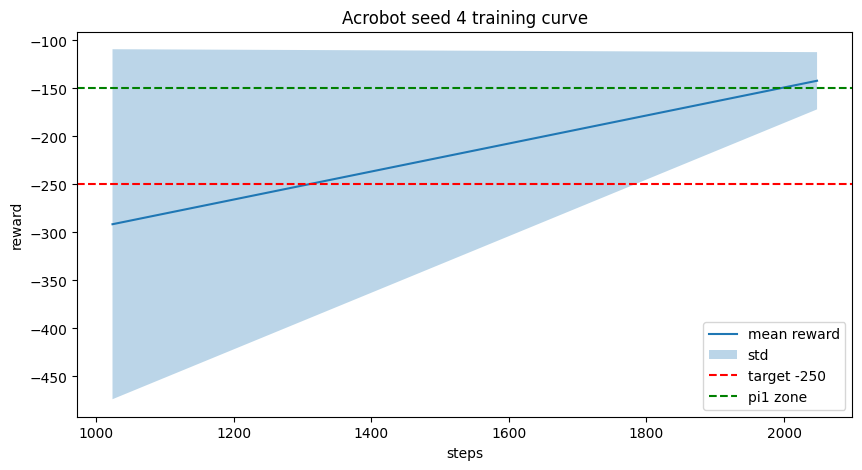

In [ ]:
env_train = gym.make("Acrobot-v1")
env_eval  = gym.make("Acrobot-v1")

env_train.reset(seed=4)
env_eval.reset(seed=10_000 + 4)

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=4,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-250, color="red",   linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 4 training curve")
plt.legend()
plt.show()

# MountainCar-v0


## Seed 0 fine-grained sweep

In [ ]:
env_train = gym.make("MountainCar-v0")
env_eval  = gym.make("MountainCar-v0")

checkpoint_interval = 1024
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -120:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(-155, color="red",   linestyle="--", label="target ~-155")
plt.axhline(-120, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("MountainCar seed 0 training curve")
plt.legend()
plt.show()

# MountainCarContinuous-v0


## Seed 0 fine-grained sweep

In [ ]:
env_train = gym.make("MountainCarContinuous-v0")
env_eval  = gym.make("MountainCarContinuous-v0")

checkpoint_interval = 2048
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 80:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(45, color="red",   linestyle="--", label="target ~45")
plt.axhline(80, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("MountainCarContinuous seed 0 — ent_coef=0.01")
plt.legend()
plt.show()

### Variant: higher entropy coefficient (`ent_coef=0.1`)
Exploring whether a larger entropy bonus helps the policy discover the mountain-climbing strategy.

In [ ]:
env_train = gym.make("MountainCarContinuous-v0")
env_eval  = gym.make("MountainCarContinuous-v0")

checkpoint_interval = 2048
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.1,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=100, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 80:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(45, color="red",   linestyle="--", label="target ~45")
plt.axhline(80, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("MountainCarContinuous seed 0 — ent_coef=0.1")
plt.legend()
plt.show()

# LunarLander-v3 

```bash 
pip install swig
pip install "gymnasium[box2d]"
```

## Seed 0 fine-grained sweep

/opt/anaconda3/envs/ee-568-rl-311/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/opt/anaconda3/envs/ee-568-rl-311/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


4096 steps: -932.4 +/- 447.9
8192 steps: -1064.4 +/- 656.8
12288 steps: -3095.8 +/- 96.8
16384 steps: -551.7 +/- 141.1
20480 steps: -540.5 +/- 214.0
24576 steps: -305.8 +/- 100.5
28672 steps: -228.4 +/- 57.5
32768 steps: -191.2 +/- 45.3
36864 steps: -318.9 +/- 99.4
40960 steps: -228.2 +/- 53.0
45056 steps: -236.4 +/- 55.6
49152 steps: -342.2 +/- 95.1
53248 steps: -272.8 +/- 86.3
57344 steps: -206.8 +/- 44.5
61440 steps: -158.0 +/- 46.6
65536 steps: -240.7 +/- 44.8
69632 steps: -125.9 +/- 22.7
73728 steps: -319.9 +/- 71.1
77824 steps: -83.6 +/- 21.1
81920 steps: -204.5 +/- 28.8
86016 steps: -343.6 +/- 96.6
90112 steps: -409.7 +/- 157.7
94208 steps: -487.0 +/- 166.8
98304 steps: -492.2 +/- 90.2
102400 steps: -145.7 +/- 60.4
106496 steps: -47.7 +/- 62.4
110592 steps: 2.9 +/- 82.7
114688 steps: 48.4 +/- 93.3
118784 steps: 66.1 +/- 100.4
122880 steps: 121.8 +/- 75.2
126976 steps: 45.2 +/- 77.1
131072 steps: -35.3 +/- 37.3
135168 steps: -9.5 +/- 35.0
139264 steps: -26.9 +/- 22.5
143360 steps

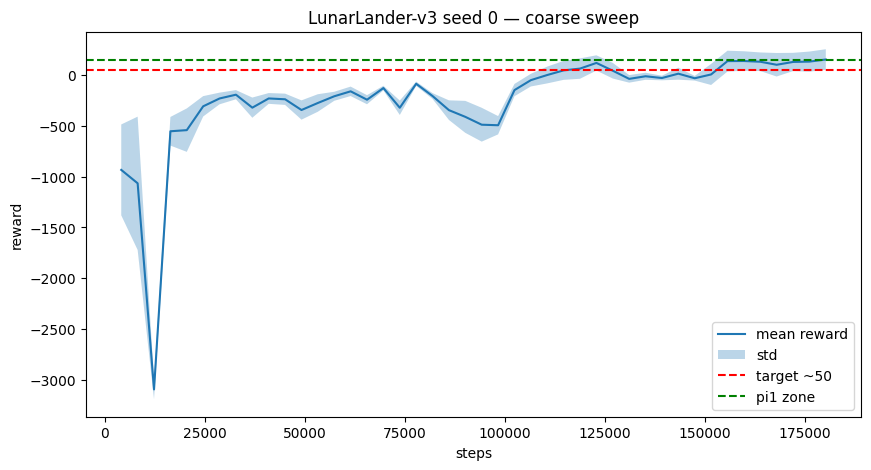

In [ ]:
env_lunarlander = gym.make("LunarLander-v3")
results_ll = []

model = PPO(
    "MlpPolicy", env_lunarlander,
    verbose=0, device="cpu", seed=0,
    learning_rate=1e-3, n_steps=1024, batch_size=64,
    n_epochs=4, gamma=0.999, gae_lambda=0.98, ent_coef=0.01,
)
total_steps = 0

for _ in range(0, 400_000, 4096):
    model.learn(total_timesteps=4096, reset_num_timesteps=False)
    total_steps += 4096
    mean_reward, std_reward = evaluate_policy(model, env_lunarlander, n_eval_episodes=100, deterministic=True)
    results_ll.append((total_steps, mean_reward, std_reward))
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
    if mean_reward > 150:
        print(f"Policy is now too good at {total_steps} steps, stopping"); break

steps_plot = [r[0] for r in results_ll]
mean_plot  = [r[1] for r in results_ll]
std_plot   = [r[2] for r in results_ll]

plt.figure(figsize=(10, 5))
plt.plot(steps_plot, mean_plot, label="mean reward")
plt.fill_between(steps_plot, [m-s for m,s in zip(mean_plot,std_plot)], [m+s for m,s in zip(mean_plot,std_plot)], alpha=0.3, label="std")
plt.axhline(50,  color="red",   linestyle="--", label="target ~50")
plt.axhline(150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps"); plt.ylabel("reward"); plt.title("LunarLander-v3 seed 0 — coarse sweep"); plt.legend(); plt.show()

## Seed 1 fine-grained sweep

4096 steps: -961.5 +/- 1075.6
8192 steps: -175.9 +/- 83.5
12288 steps: -96.9 +/- 38.9
16384 steps: -13.8 +/- 144.0
20480 steps: -67.1 +/- 114.6
24576 steps: -400.3 +/- 176.9
28672 steps: -274.7 +/- 115.3
32768 steps: -252.3 +/- 94.0
36864 steps: -343.7 +/- 133.0
40960 steps: -353.6 +/- 139.8
45056 steps: -233.5 +/- 123.3
49152 steps: -228.0 +/- 153.2
53248 steps: -178.0 +/- 104.0
57344 steps: -100.4 +/- 48.9
61440 steps: -111.7 +/- 118.8
65536 steps: -131.2 +/- 126.6
69632 steps: -139.8 +/- 83.2
73728 steps: -109.0 +/- 163.2
77824 steps: -150.0 +/- 153.9
81920 steps: -121.7 +/- 184.0
86016 steps: -54.3 +/- 106.7
90112 steps: -63.6 +/- 95.1
94208 steps: -120.5 +/- 115.0
98304 steps: -192.3 +/- 242.5
102400 steps: -226.0 +/- 169.8
106496 steps: -178.9 +/- 115.9
110592 steps: -161.6 +/- 62.4
114688 steps: -421.2 +/- 311.4
118784 steps: -550.3 +/- 394.8
122880 steps: -382.4 +/- 389.4
126976 steps: -69.2 +/- 105.3
131072 steps: 12.0 +/- 113.0
135168 steps: 5.5 +/- 109.4
139264 steps: 52.3 +

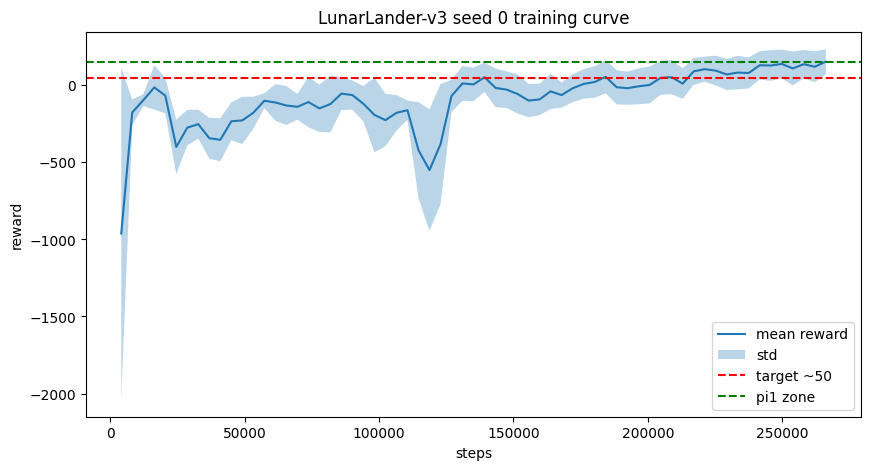

In [ ]:
env_train = gym.make("LunarLander-v3")
env_eval  = gym.make("LunarLander-v3")

env_train.reset(seed=1)
env_eval.reset(seed=10_000)

checkpoint_interval = 4096
steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy", env_train,
    verbose=0, device="cpu", seed=1,
    learning_rate=1e-3, n_steps=1024, batch_size=64,
    n_epochs=4, gamma=0.999, gae_lambda=0.98, ent_coef=0.01,
)
total_steps = 0

for _ in range(0, 400_000, checkpoint_interval):
    model.learn(total_timesteps=checkpoint_interval, reset_num_timesteps=False)
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(model, env_eval, n_eval_episodes=100, deterministic=True)
    steps_log.append(total_steps); mean_log.append(mean_reward); std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
    if mean_reward > 150:
        print(f"Policy is now too good at {total_steps} steps, stopping"); break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log, [m-s for m,s in zip(mean_log,std_log)], [m+s for m,s in zip(mean_log,std_log)], alpha=0.3, label="std")
plt.axhline(50,  color="red",   linestyle="--", label="target ~50")
plt.axhline(150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps"); plt.ylabel("reward"); plt.title("LunarLander-v3 seed 1 training curve"); plt.legend(); plt.show()

# Pendulum 

## Seed 0 fine-grained sweep

1024 steps: -1190.5 +/- 311.5
2048 steps: -1139.9 +/- 271.7
3072 steps: -1170.1 +/- 257.3
4096 steps: -1155.2 +/- 256.9
5120 steps: -1188.9 +/- 308.4
6144 steps: -1200.3 +/- 333.7
7168 steps: -1192.7 +/- 329.4
8192 steps: -1193.8 +/- 364.9
9216 steps: -1243.6 +/- 360.8
10240 steps: -1211.3 +/- 339.3
11264 steps: -1166.3 +/- 303.7
12288 steps: -1141.2 +/- 225.9
13312 steps: -1185.5 +/- 245.0
14336 steps: -1209.6 +/- 283.9
15360 steps: -1209.7 +/- 282.9
16384 steps: -1189.2 +/- 245.4
17408 steps: -1146.3 +/- 283.8
18432 steps: -1218.4 +/- 279.9
19456 steps: -1180.5 +/- 323.6
20480 steps: -1148.7 +/- 264.3
21504 steps: -1171.9 +/- 296.1
22528 steps: -1157.6 +/- 272.3
23552 steps: -1171.8 +/- 243.6
24576 steps: -1150.6 +/- 224.2
25600 steps: -1181.6 +/- 226.3
26624 steps: -1230.6 +/- 294.3
27648 steps: -1165.5 +/- 255.2
28672 steps: -1168.1 +/- 262.8
29696 steps: -1178.7 +/- 279.2
30720 steps: -1154.3 +/- 280.9
31744 steps: -1169.0 +/- 271.4
32768 steps: -1164.9 +/- 303.1
33792 steps: -118

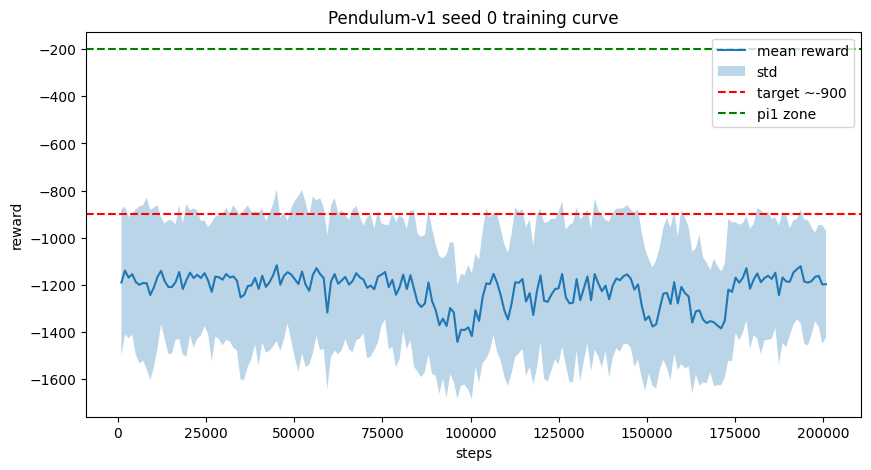

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=0)
env_eval.reset(seed=10_000)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 0 training curve")
plt.legend()
plt.show()

### Increase n_steps 

/opt/anaconda3/envs/ee-568-rl-311/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


1024 steps: -1183.2 +/- 309.3
2048 steps: -1138.5 +/- 266.9
3072 steps: -1172.9 +/- 243.6
4096 steps: -1152.8 +/- 236.8
5120 steps: -1191.4 +/- 259.1
6144 steps: -1186.5 +/- 261.2
7168 steps: -1166.7 +/- 288.3
8192 steps: -1174.4 +/- 325.9
9216 steps: -1230.4 +/- 325.9
10240 steps: -1202.2 +/- 317.2
11264 steps: -1165.0 +/- 307.1
12288 steps: -1122.7 +/- 273.0
13312 steps: -1176.7 +/- 288.8
14336 steps: -1212.1 +/- 304.1
15360 steps: -1200.7 +/- 303.7
16384 steps: -1199.0 +/- 273.9
17408 steps: -1145.4 +/- 285.8
18432 steps: -1217.6 +/- 281.9
19456 steps: -1183.8 +/- 330.0
20480 steps: -1150.2 +/- 280.1
21504 steps: -1182.3 +/- 315.1
22528 steps: -1162.7 +/- 289.9
23552 steps: -1164.5 +/- 273.3
24576 steps: -1151.5 +/- 241.7
25600 steps: -1182.6 +/- 252.3
26624 steps: -1227.9 +/- 294.8
27648 steps: -1165.6 +/- 254.3
28672 steps: -1172.2 +/- 247.1
29696 steps: -1179.2 +/- 269.3
30720 steps: -1153.8 +/- 274.1
31744 steps: -1164.2 +/- 265.8
32768 steps: -1160.3 +/- 284.5
33792 steps: -116

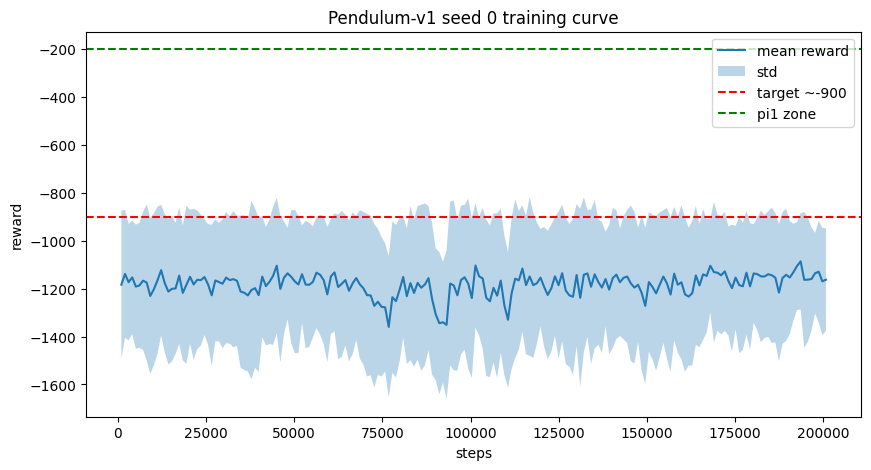

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=0)
env_eval.reset(seed=10_000)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 0 training curve")
plt.legend()
plt.show()

1024 steps: -1156.0 +/- 280.4
2048 steps: -1140.6 +/- 226.2
3072 steps: -1160.9 +/- 209.9
4096 steps: -1151.3 +/- 250.0
5120 steps: -1179.9 +/- 237.4
6144 steps: -1192.0 +/- 247.3
7168 steps: -1165.0 +/- 273.0
8192 steps: -1167.8 +/- 277.8
9216 steps: -1235.9 +/- 284.2
10240 steps: -1209.9 +/- 337.8
11264 steps: -1167.2 +/- 311.6
12288 steps: -1122.4 +/- 283.6
13312 steps: -1175.6 +/- 290.6
14336 steps: -1224.7 +/- 311.9
15360 steps: -1208.6 +/- 319.5
16384 steps: -1205.3 +/- 287.2
17408 steps: -1162.2 +/- 320.0
18432 steps: -1247.6 +/- 337.9
19456 steps: -1188.4 +/- 329.9
20480 steps: -1152.8 +/- 266.5
21504 steps: -1172.3 +/- 290.8
22528 steps: -1184.1 +/- 319.9
23552 steps: -1164.8 +/- 262.9
24576 steps: -1148.9 +/- 210.6
25600 steps: -1179.0 +/- 269.1
26624 steps: -1223.2 +/- 284.4
27648 steps: -1161.3 +/- 252.0
28672 steps: -1179.0 +/- 332.6
29696 steps: -1223.1 +/- 337.0
30720 steps: -1159.8 +/- 311.5
31744 steps: -1158.0 +/- 244.7
32768 steps: -1167.8 +/- 307.4
33792 steps: -116

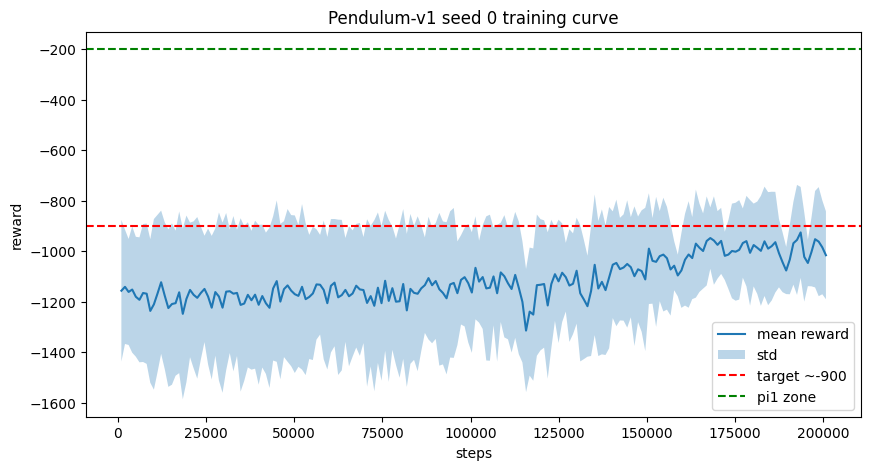

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=0)
env_eval.reset(seed=10_000)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 0 training curve")
plt.legend()
plt.show()

### Increase nb steps and lr 

/opt/anaconda3/envs/ee-568-rl-311/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


1024 steps: -1158.1 +/- 282.0
2048 steps: -1140.5 +/- 231.6
3072 steps: -1165.5 +/- 217.9
4096 steps: -1152.8 +/- 264.7
5120 steps: -1188.6 +/- 276.8
6144 steps: -1199.3 +/- 317.2
7168 steps: -1245.6 +/- 308.5
8192 steps: -1163.7 +/- 379.1
9216 steps: -1249.2 +/- 341.5
10240 steps: -1261.4 +/- 366.1
11264 steps: -1170.1 +/- 313.0
12288 steps: -1139.7 +/- 331.7
13312 steps: -1180.5 +/- 262.2
14336 steps: -1230.0 +/- 343.1
15360 steps: -1211.1 +/- 310.4
16384 steps: -1193.1 +/- 246.3
17408 steps: -1154.2 +/- 304.2
18432 steps: -1284.3 +/- 328.5
19456 steps: -1184.8 +/- 334.1
20480 steps: -1161.8 +/- 263.7
21504 steps: -1182.8 +/- 276.8
22528 steps: -1173.7 +/- 321.1
23552 steps: -1172.5 +/- 250.6
24576 steps: -1147.5 +/- 248.6
25600 steps: -1189.3 +/- 308.0
26624 steps: -1292.6 +/- 356.8
27648 steps: -1174.9 +/- 306.0
28672 steps: -1226.1 +/- 329.3
29696 steps: -1226.1 +/- 343.9
30720 steps: -1152.5 +/- 334.4
31744 steps: -1168.2 +/- 264.8
32768 steps: -1171.3 +/- 276.1
33792 steps: -115

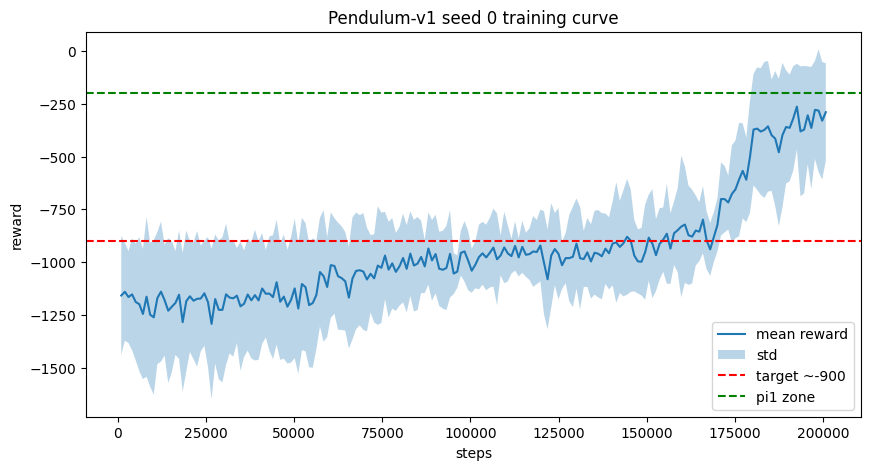

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=0)
env_eval.reset(seed=10_000)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 0 training curve")
plt.legend()
plt.show()

## Seed 1 fine-grained sweep

1024 steps: -1220.4 +/- 338.1
2048 steps: -1212.3 +/- 312.2
3072 steps: -1199.6 +/- 330.2
4096 steps: -1148.3 +/- 289.0
5120 steps: -1200.6 +/- 262.6
6144 steps: -1215.2 +/- 310.4
7168 steps: -1223.0 +/- 312.8
8192 steps: -1281.9 +/- 359.6
9216 steps: -1162.2 +/- 257.6
10240 steps: -1144.9 +/- 185.8
11264 steps: -1150.6 +/- 263.2
12288 steps: -1151.9 +/- 215.3
13312 steps: -1171.7 +/- 266.1
14336 steps: -1154.2 +/- 199.2
15360 steps: -1159.9 +/- 200.4
16384 steps: -1197.5 +/- 248.7
17408 steps: -1154.7 +/- 211.6
18432 steps: -1182.0 +/- 253.1
19456 steps: -1179.4 +/- 302.9
20480 steps: -1135.1 +/- 259.0
21504 steps: -1161.2 +/- 282.2
22528 steps: -1150.5 +/- 258.3
23552 steps: -1195.8 +/- 286.3
24576 steps: -1173.1 +/- 268.9
25600 steps: -1178.8 +/- 235.9
26624 steps: -1167.6 +/- 307.5
27648 steps: -1155.2 +/- 248.4
28672 steps: -1202.4 +/- 260.3
29696 steps: -1226.3 +/- 249.6
30720 steps: -1180.7 +/- 318.6
31744 steps: -1139.3 +/- 271.2
32768 steps: -1146.2 +/- 229.4
33792 steps: -113

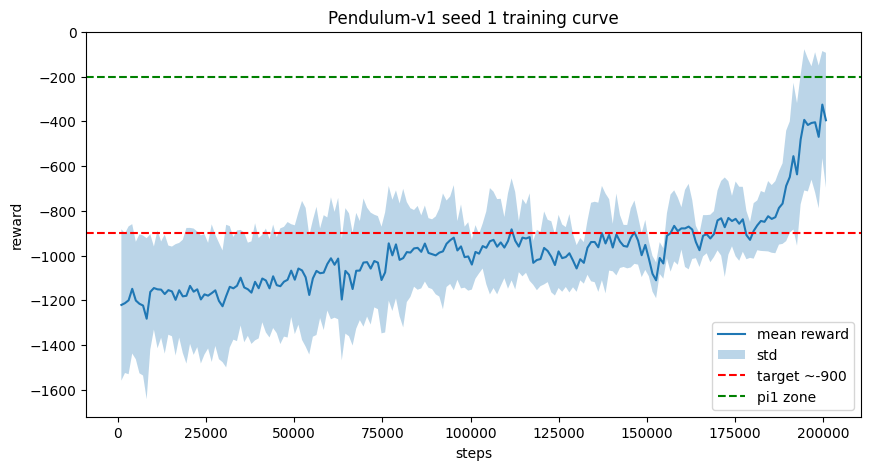

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=1)
env_eval.reset(seed=10_000 + 1)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 1 training curve")
plt.legend()
plt.show()

## Seed 2 fine-grained sweep

1024 steps: -1234.3 +/- 294.5
2048 steps: -1168.3 +/- 348.9
3072 steps: -1202.0 +/- 273.0
4096 steps: -1207.0 +/- 329.7
5120 steps: -1223.7 +/- 338.9
6144 steps: -1203.5 +/- 296.2
7168 steps: -1204.1 +/- 360.9
8192 steps: -1156.5 +/- 261.4
9216 steps: -1162.9 +/- 310.7
10240 steps: -1241.6 +/- 369.2
11264 steps: -1165.9 +/- 304.6
12288 steps: -1206.3 +/- 348.4
13312 steps: -1154.2 +/- 265.4
14336 steps: -1146.2 +/- 214.1
15360 steps: -1224.5 +/- 305.4
16384 steps: -1240.2 +/- 310.6
17408 steps: -1300.6 +/- 305.0
18432 steps: -1366.8 +/- 292.3
19456 steps: -1222.6 +/- 289.3
20480 steps: -1268.9 +/- 358.1
21504 steps: -1176.8 +/- 278.3
22528 steps: -1205.1 +/- 288.4
23552 steps: -1171.0 +/- 300.3
24576 steps: -1211.9 +/- 287.7
25600 steps: -1232.4 +/- 314.6
26624 steps: -1253.1 +/- 334.6
27648 steps: -1170.1 +/- 283.1
28672 steps: -1196.9 +/- 291.2
29696 steps: -1136.5 +/- 279.2
30720 steps: -1165.5 +/- 249.9
31744 steps: -1156.0 +/- 239.5
32768 steps: -1161.9 +/- 270.6
33792 steps: -123

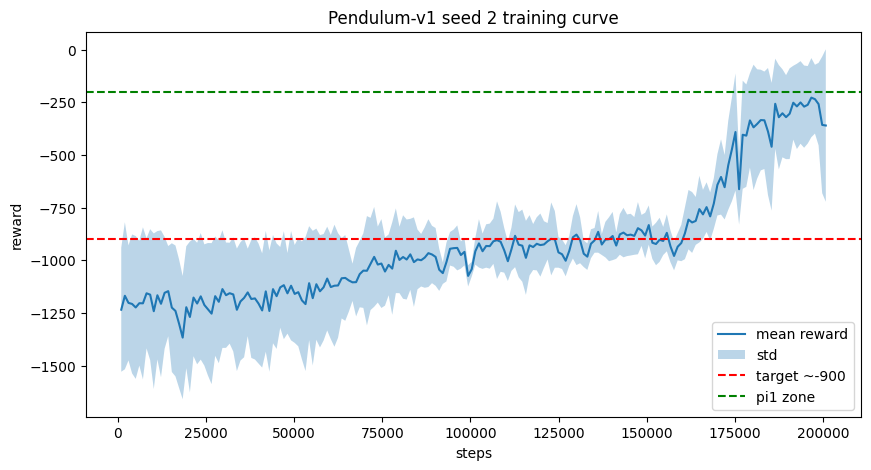

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=2)
env_eval.reset(seed=10_000 + 2)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=2,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 2 training curve")
plt.legend()
plt.show()

## Seed 3 fine-grained sweep

1024 steps: -1240.5 +/- 334.8
2048 steps: -1212.5 +/- 304.4
3072 steps: -1205.6 +/- 297.5
4096 steps: -1171.3 +/- 238.3
5120 steps: -1100.9 +/- 280.1
6144 steps: -1164.5 +/- 261.7
7168 steps: -1212.4 +/- 350.7
8192 steps: -1134.0 +/- 331.8
9216 steps: -1321.5 +/- 289.3
10240 steps: -1287.5 +/- 277.5
11264 steps: -1179.1 +/- 324.4
12288 steps: -1258.2 +/- 296.3
13312 steps: -1192.2 +/- 292.8
14336 steps: -1140.0 +/- 254.0
15360 steps: -1180.7 +/- 229.3
16384 steps: -1183.2 +/- 216.5
17408 steps: -1185.7 +/- 272.0
18432 steps: -1167.1 +/- 257.1
19456 steps: -1171.4 +/- 212.0
20480 steps: -1146.4 +/- 226.0
21504 steps: -1157.5 +/- 239.4
22528 steps: -1144.9 +/- 288.0
23552 steps: -1135.0 +/- 235.1
24576 steps: -1167.6 +/- 266.1
25600 steps: -1117.5 +/- 230.4
26624 steps: -1138.4 +/- 180.4
27648 steps: -1119.4 +/- 216.0
28672 steps: -1109.5 +/- 296.0
29696 steps: -1121.6 +/- 215.5
30720 steps: -1129.9 +/- 327.0
31744 steps: -1175.4 +/- 269.5
32768 steps: -1162.8 +/- 251.3
33792 steps: -114

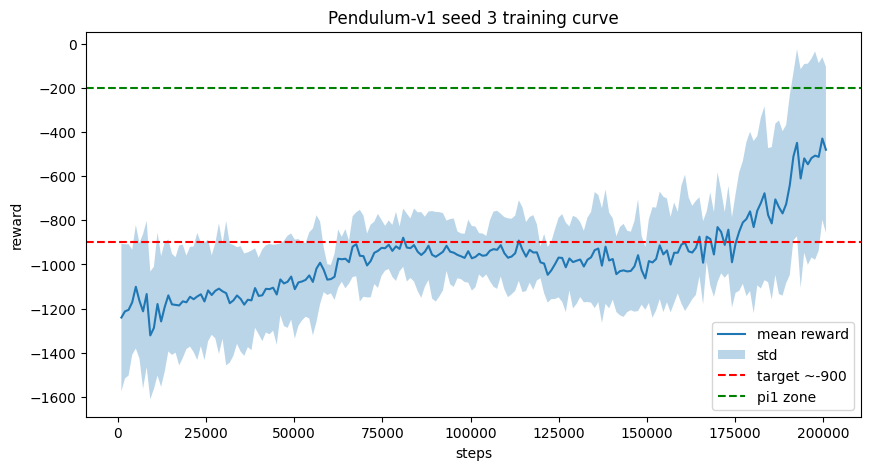

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=3)
env_eval.reset(seed=10_000 + 3)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=3,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 3 training curve")
plt.legend()
plt.show()

## Seed 4 fine-grained sweep

1024 steps: -1177.4 +/- 279.0
2048 steps: -1197.3 +/- 253.4
3072 steps: -1208.6 +/- 272.3
4096 steps: -1188.3 +/- 256.5
5120 steps: -1146.4 +/- 303.3
6144 steps: -1289.9 +/- 320.7
7168 steps: -1206.8 +/- 319.4
8192 steps: -1153.7 +/- 264.8
9216 steps: -1131.5 +/- 226.1
10240 steps: -1171.2 +/- 201.6
11264 steps: -1149.7 +/- 134.3
12288 steps: -1138.8 +/- 164.6
13312 steps: -1130.2 +/- 205.0
14336 steps: -1183.9 +/- 204.4
15360 steps: -1121.1 +/- 194.0
16384 steps: -1126.8 +/- 238.3
17408 steps: -1158.5 +/- 308.1
18432 steps: -1124.0 +/- 223.8
19456 steps: -1195.6 +/- 261.2
20480 steps: -1136.3 +/- 210.5
21504 steps: -1092.4 +/- 252.5
22528 steps: -1155.9 +/- 239.7
23552 steps: -1188.6 +/- 247.9
24576 steps: -1139.0 +/- 264.3
25600 steps: -1119.4 +/- 294.7
26624 steps: -1109.2 +/- 214.7
27648 steps: -1137.0 +/- 246.8
28672 steps: -1141.0 +/- 202.2
29696 steps: -1170.8 +/- 175.9
30720 steps: -1149.1 +/- 223.2
31744 steps: -1095.9 +/- 247.4
32768 steps: -1138.5 +/- 268.3
33792 steps: -120

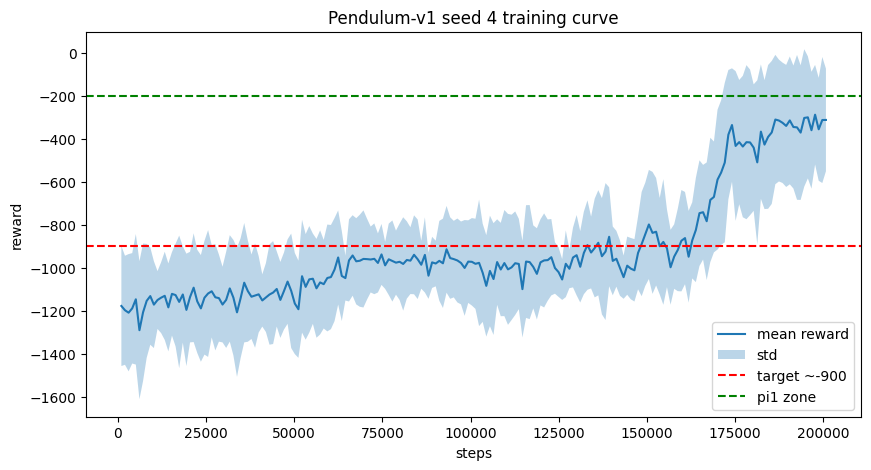

In [ ]:
env_train = gym.make("Pendulum-v1")
env_eval = gym.make("Pendulum-v1")

checkpoint_interval = 1024


env_train.reset(seed=4)
env_eval.reset(seed=10_000 + 4)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=4,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -200:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-900, color="red", linestyle="--", label="target ~-900")
plt.axhline(-200, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Pendulum-v1 seed 4 training curve")
plt.legend()
plt.show()